In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
df = pd.read_csv('./Salary_Data.csv')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  33 non-null     float64
 1   Salary           33 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 660.0 bytes


In [6]:
df.describe()


,YearsExperience,Salary
count,33.000000,33.000000
mean,5.921212,82760.303030
std,3.342413,34014.620992
min,1.100000,37731.000000
25%,3.200000,56957.000000
50%,5.100000,67938.000000
75%,8.700000,109431.000000
max,13.000000,156000.000000


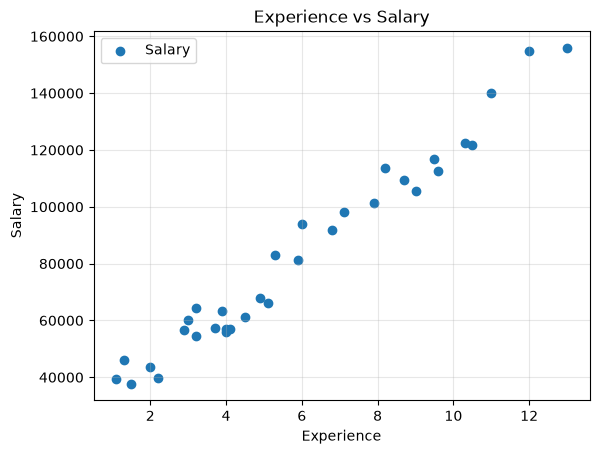

In [7]:
plt.scatter(df['YearsExperience'], df['Salary'], label="Salary")
plt.xlabel("Experience")
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.legend()
plt.grid(alpha=0.3)

In [8]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.983642
Salary,0.983642,1.000000


In [9]:
x = df['YearsExperience']
y = df['Salary']

In [10]:
x = tf.constant(x)
y = tf.constant(y)

In [11]:
# create a model
model = tf.keras.Sequential([
    # add an input layer with 1 neuron
    # add a hidden layer with 32 neurons
    tf.keras.layers.Dense(32, activation='relu', input_shape=[1]),

    # add a hidden layer with 16 neurons
    tf.keras.layers.Dense(16, activation='relu'),

    # add an output layer with 1 neuron
    tf.keras.layers.Dense(1)
])

C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# compile the model
model.compile(
    # optimizer used to optmize the parameters
    optimizer=tf.optimizers.Adam(),

    # MSE used to calculate the loss / error
    loss=tf.losses.MSE,

    # get accuracy of every epoch
    metrics=['r2_score']
)

In [14]:

history = model.fit(x, y, epochs=1000)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 7900841472.0000 - r2_score: -6.0422
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7899901952.0000 - r2_score: -6.0413
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 7898960384.0000 - r2_score: -6.0405
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7898036736.0000 - r2_score: -6.0397
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 7897047040.0000 - r2_score: -6.0388
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7896077312.0000 - r2_score: -6.0379
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7894998528.0000 - r2_score: -6.0370
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7893947392.0000 - r2_score: -6.0360
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7892858880.0000 - r2_score: -6.0350
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 7891739136.0000 - r2_score: -6.0340
Epoch 11/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/st

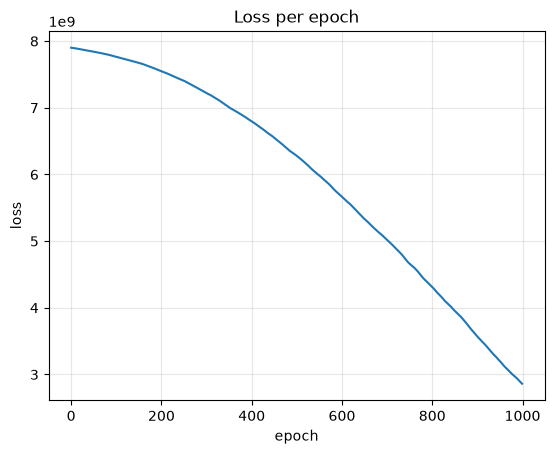

In [15]:
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Loss per epoch')
plt.grid(alpha=0.3)

In [16]:
model.save('salary_prediction.h5')

In [17]:
# create the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# convert the model to tflite format
tflite_model = converter.convert()

# save the tflite model
with open('salary_prediction.tflite', 'wb') as file:
    file.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpil3e6skw\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpil3e6skw\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpil3e6skw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2346269745680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2346269743184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2346269742416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2346269740112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2346269747024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2346269744336: TensorSpec(shape=(), dtype=tf.resource, name=None)
